# PowerTransformer
--------------------------------------------------------------------------------
* A technique used to make numerical data resemble a `Gaussian distribution` more closely, which is often required for many machine learning models that operate under the assumption of normal distribution
* Valuable in situations where data shows significant `skewness` or `kurtosis`

--------------------------------------------------------------------------------
* Two main transformations:
    * **Box-Cox Transform**
    * **Yeo-Johnson Transform**
   
Both of these methods are used to compute optimal transformation parameter λ that normalizes the data

## Box-Cox Transform

------------------------------------------------------------------------------
* A statistical method used to `stablize variance` and make data more closely meet the assumptions of normality
* Can be applied to positive data
* Parameterized by (λ) value, which varies to find the best approximation of a normal distribution
------------------------------------------------------------------------------
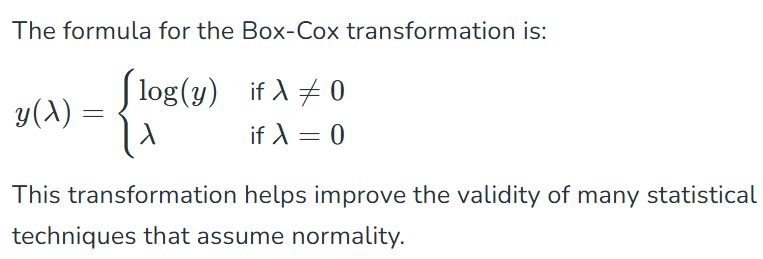

## Yeo-Johnson Transform

------------------------------------------------------------------------------
* An extension of the Box-Cox method, serves to stabilize variance and normalize distributions, rendering it more adaptable for real-world scenarios by accommodating both positive and negative data values
------------------------------------------------------------------------------
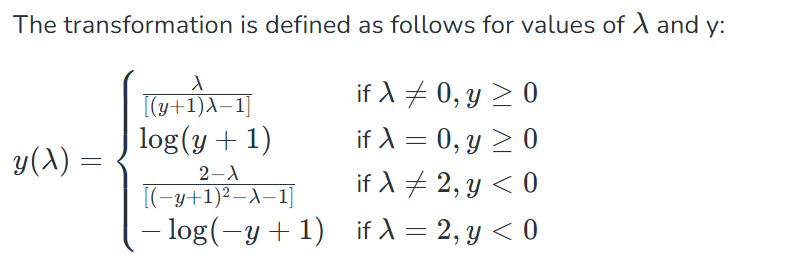

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [184]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [230]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [231]:
df.shape

(1030, 9)

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [233]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [234]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [235]:
df.duplicated().sum()

np.int64(25)

In [236]:
df[df.duplicated(keep=False)]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
95,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
100,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
103,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20


In [237]:
df.drop_duplicates(inplace=True)

In [238]:
df.duplicated().sum()

np.int64(0)

In [239]:
df.shape

(1005, 9)

In [240]:
X = df.drop(columns=['Strength'])
y = df['Strength']

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [242]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(804, 8)
(201, 8)
(804,)
(201,)


In [243]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,804.0,278.184577,103.939773,102.0,190.300,265.5,349.000,540.0
Blast Furnace Slag,804.0,72.068781,86.089886,0.0,0.000,20.0,140.325,359.4
Fly Ash,804.0,56.325498,64.348425,0.0,0.000,0.0,118.300,200.1
Water,804.0,182.108955,21.535828,121.8,166.600,185.7,192.175,246.9
Superplasticizer,804.0,6.082338,5.949140,0.0,0.000,6.1,10.000,32.2
Coarse Aggregate,804.0,972.604975,77.291942,801.0,932.000,968.0,1028.400,1134.3
Fine Aggregate,804.0,773.419154,80.922066,594.0,728.675,780.2,825.000,992.6
Age,804.0,45.313433,62.352281,1.0,14.000,28.0,56.000,365.0


In [244]:
# applying regression without any transformation 
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.5801703029028777

In [245]:
# cross validation
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.47680010562839037)

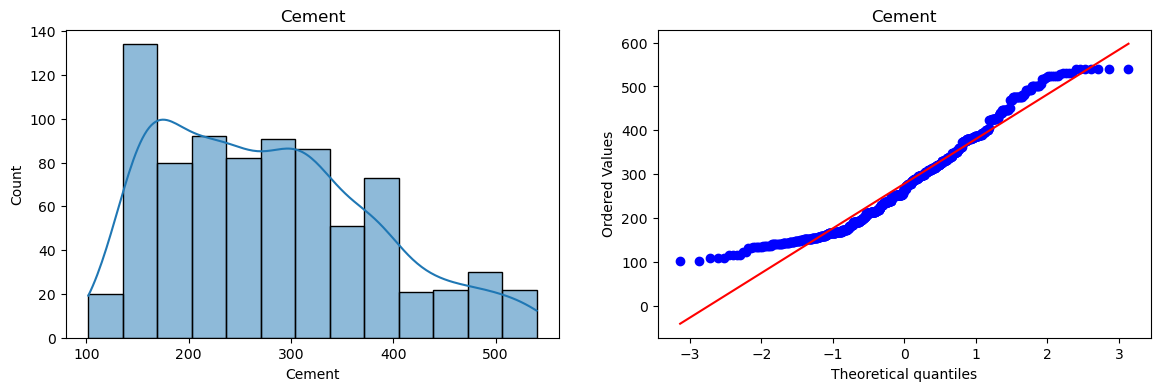

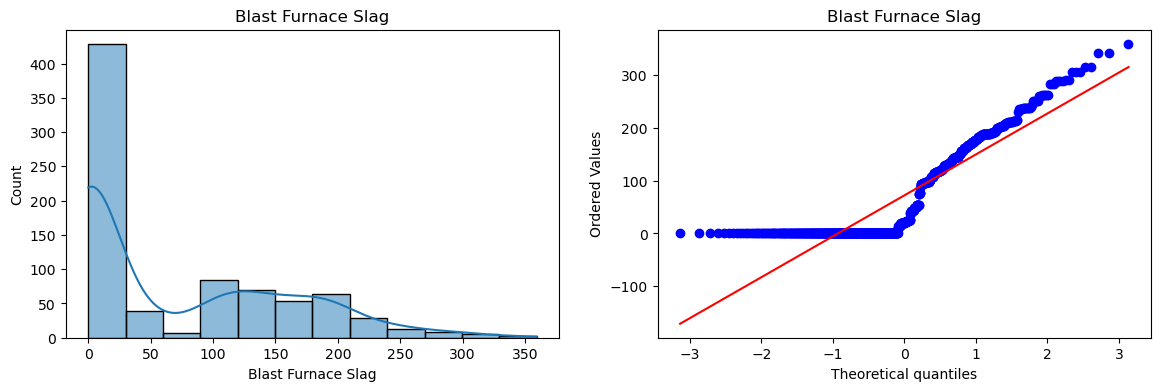

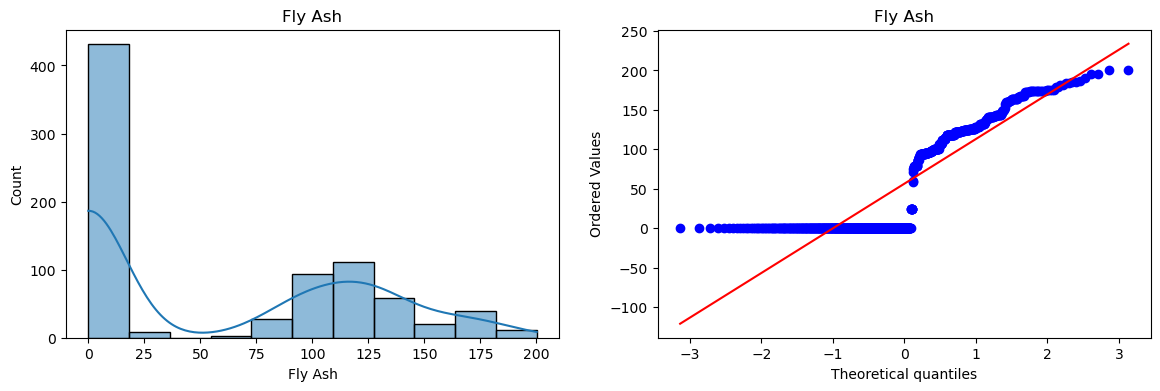

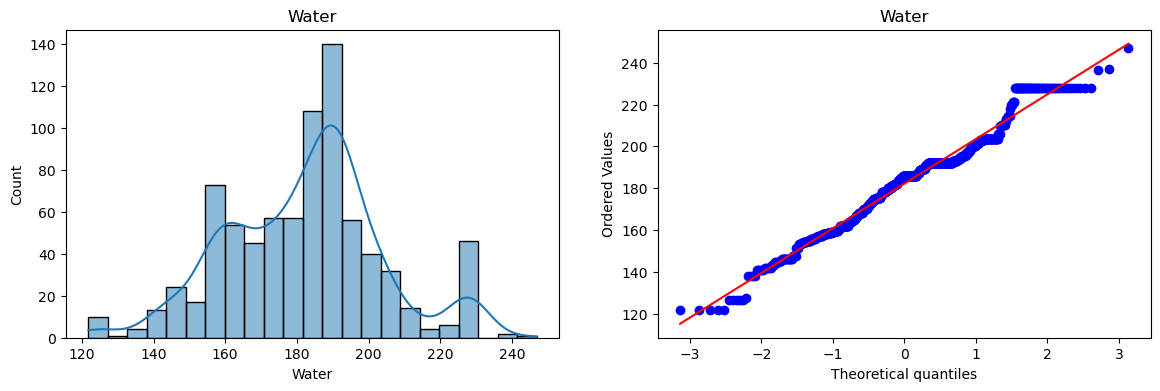

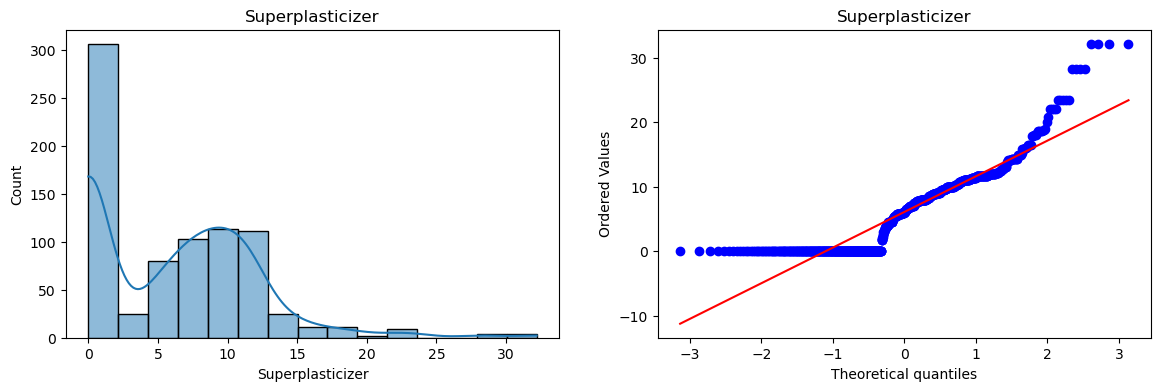

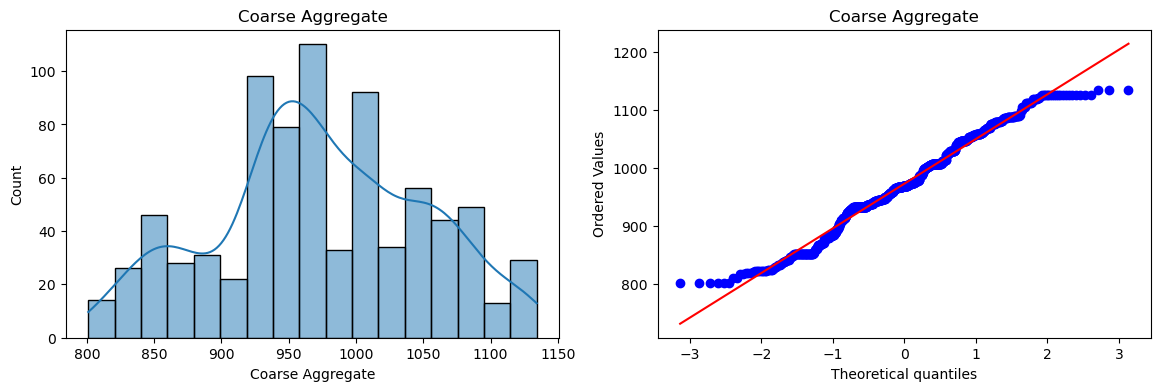

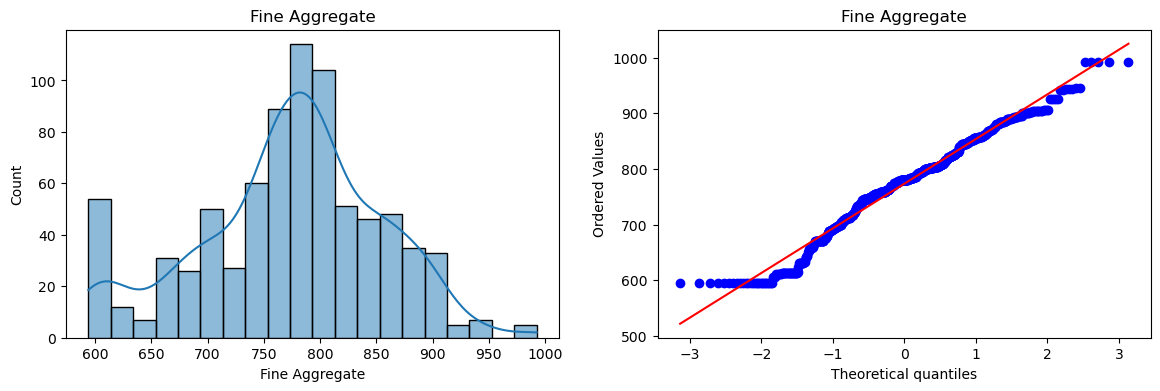

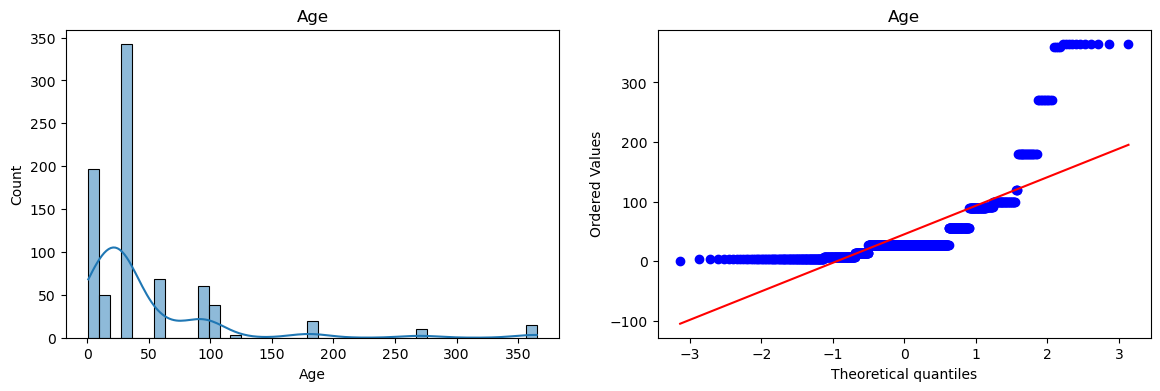

In [246]:
# plotting the distplots without any transformation
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(col)

    plt.show()

In [256]:
# applying Box-Cox Transformation
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.0000001)
X_test_transformed = pt.transform(X_test+0.0000001)

pd.DataFrame({'cols':X_train.columns, 'box-cox-lambdas':pt.lambdas_})

,cols,box-cox-lambdas
0,Cement,0.101285
1,Blast Furnace Slag,0.019807
2,Fly Ash,-0.020932
3,Water,0.950247
4,Superplasticizer,0.083333
5,Coarse Aggregate,1.198571
6,Fine Aggregate,1.911749
7,Age,0.051998


In [258]:
# applying linear regression on transformed data
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)

y_pred = lr.predict(X_test_transformed)

r2_score(y_test,y_pred)

0.793866877850437

In [259]:
# cross validation
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)


np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6756775573240262)

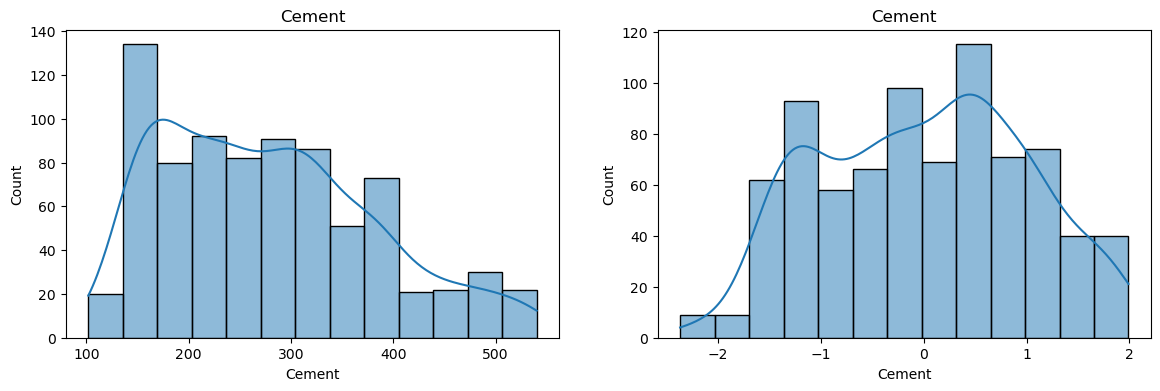

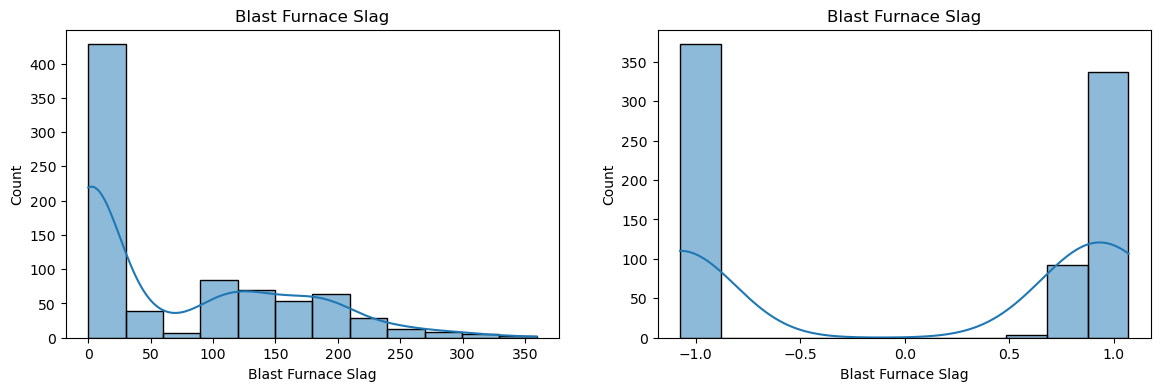

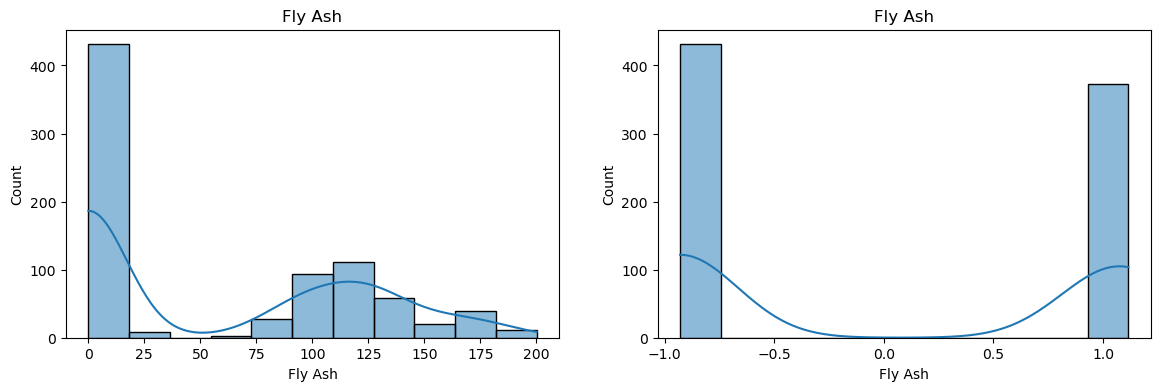

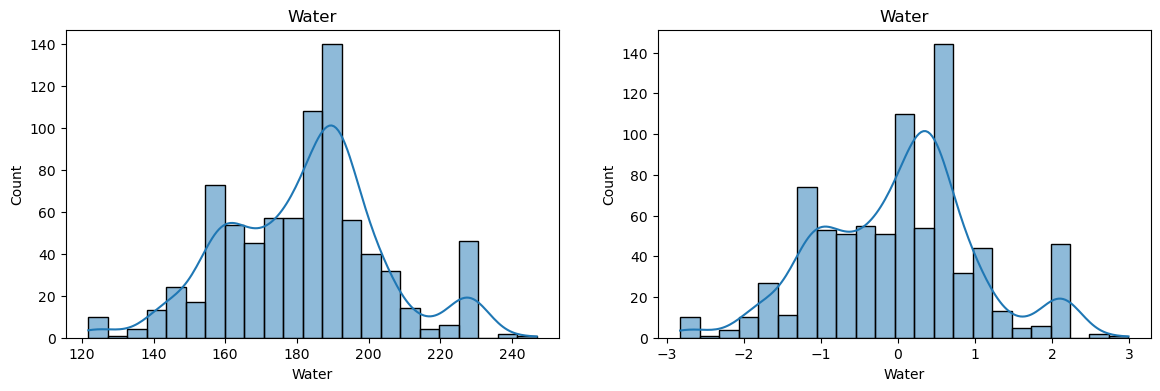

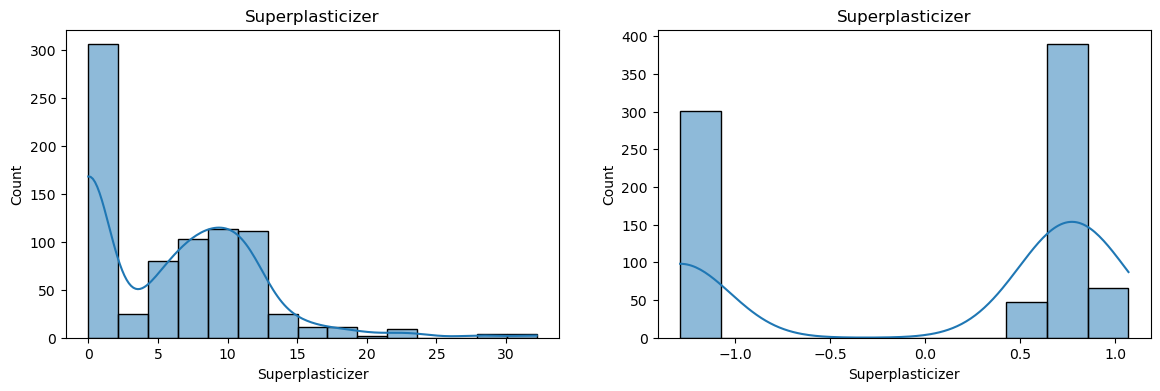

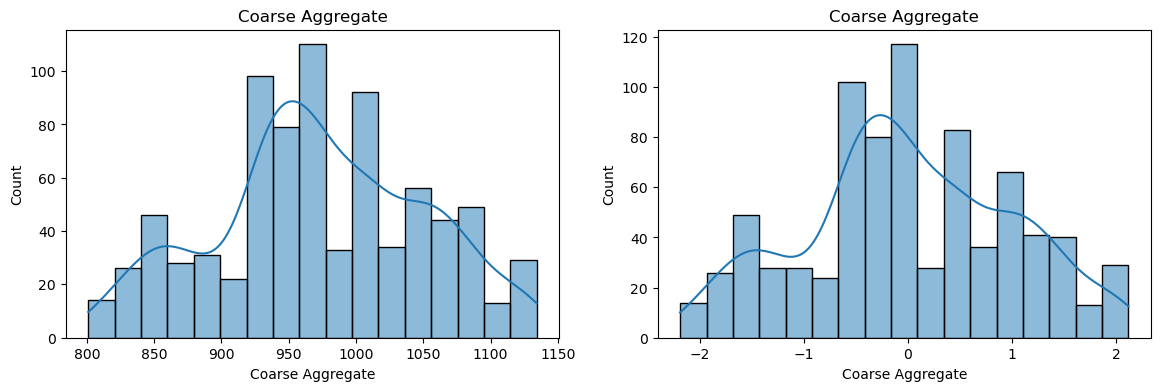

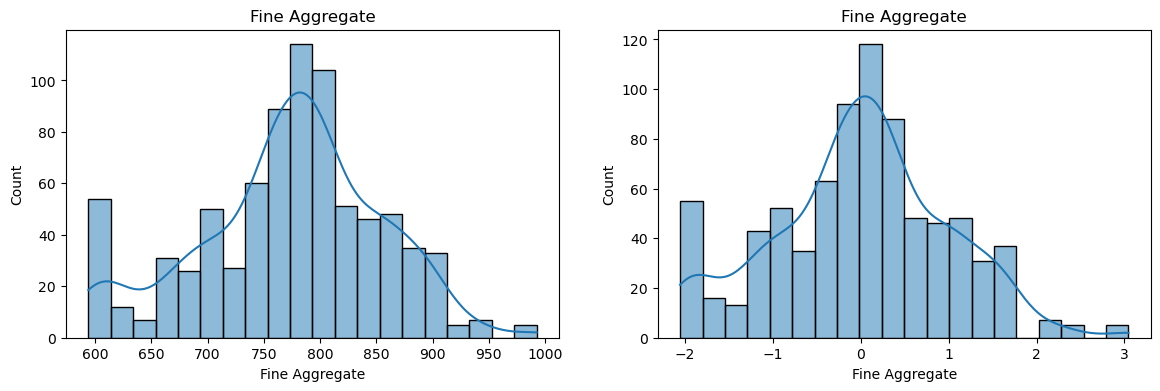

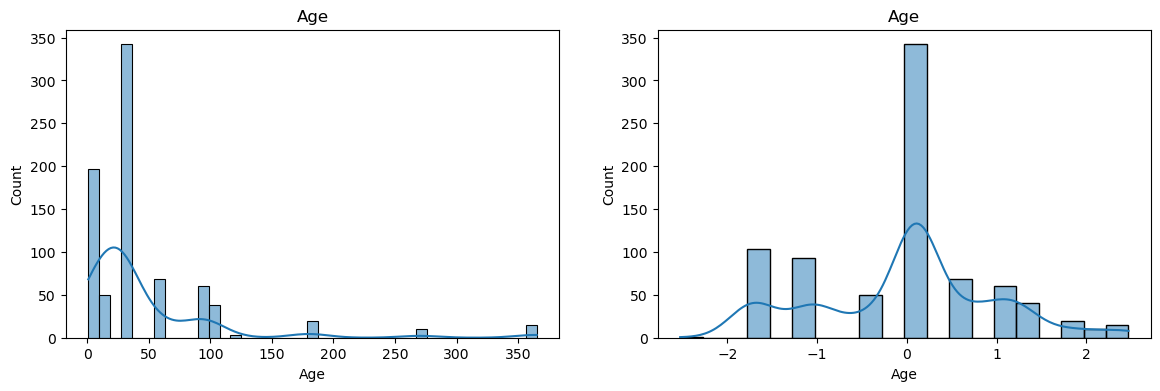

In [277]:
# before and after comparison for Box-Cox plot
X_train_transformed = pd.DataFrame(X_train_transformed, columns= X_train.columns)
for col in X_train_transformed:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde = True)
    plt.title(col)

    plt.show()

In [269]:
# applying yeo-johnson transform
yeo_pt = PowerTransformer()

X_train_transformed_yeo = yeo_pt.fit_transform(X_train)
X_test_transformed_yeo = yeo_pt.transform(X_test)

In [272]:
lr = LinearRegression()

lr.fit(X_train_transformed_yeo, y_train)

y_pred_yeo = lr.predict(X_test_transformed_yeo)

r2_score(y_test, y_pred_yeo)

0.7955560586024052

In [273]:
pd.DataFrame({'cols':X_train.columns, 'Yeo-Johnson-lambdas': yeo_pt.lambdas_})

,cols,Yeo-Johnson-lambdas
0,Cement,0.098283
1,Blast Furnace Slag,0.001796
2,Fly Ash,-0.101005
3,Water,0.949883
4,Superplasticizer,0.242384
5,Coarse Aggregate,1.198868
6,Fine Aggregate,1.912998
7,Age,0.005200


In [278]:
# cross validation
power_transform = PowerTransformer()

X_transformed_yeo = power_transform.fit_transform(X)
np.mean(cross_val_score(lr,X_transformed_yeo,y,scoring='r2'))

np.float64(0.6938787275349625)

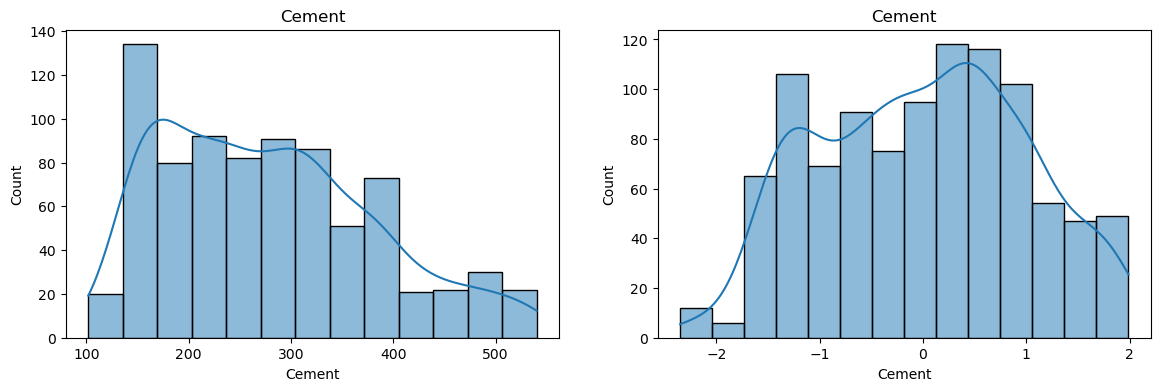

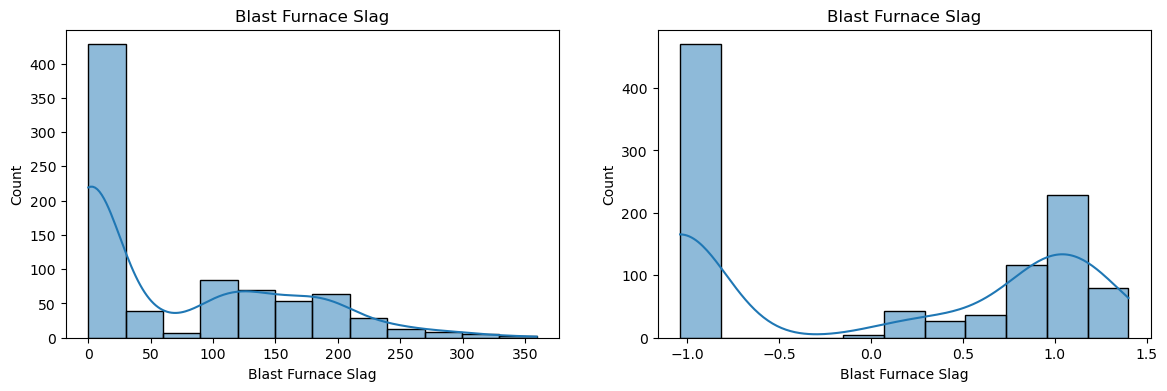

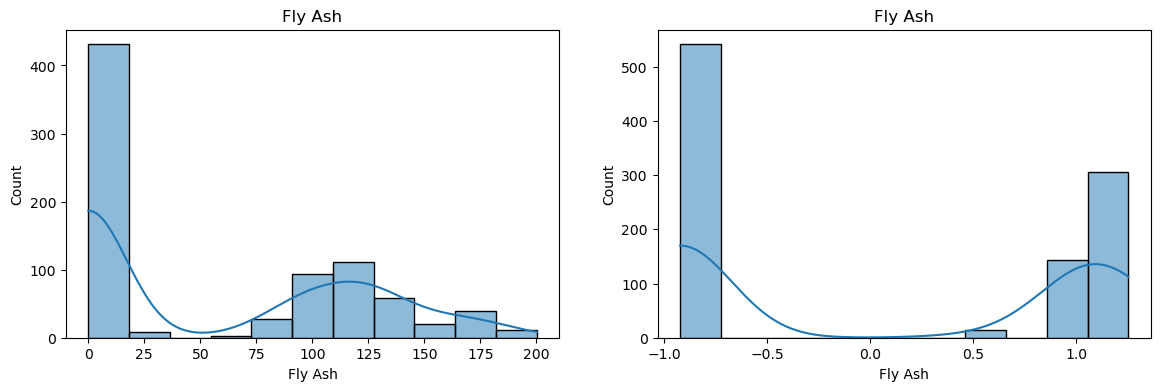

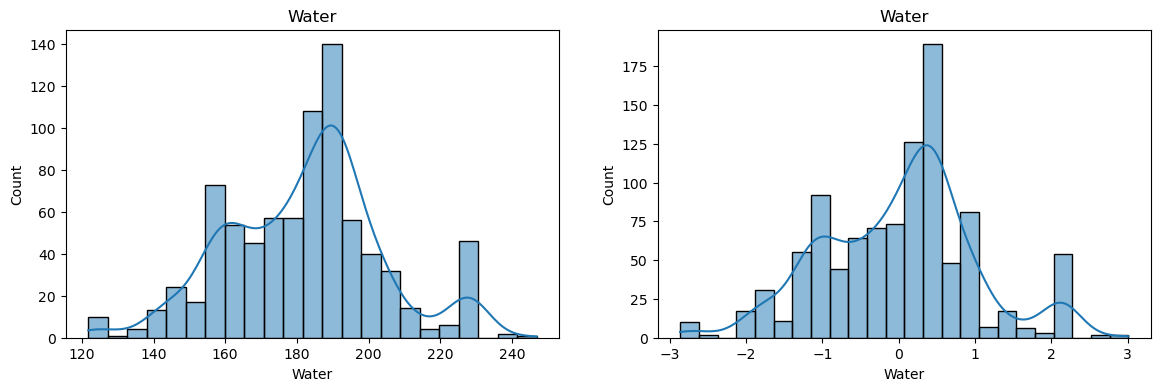

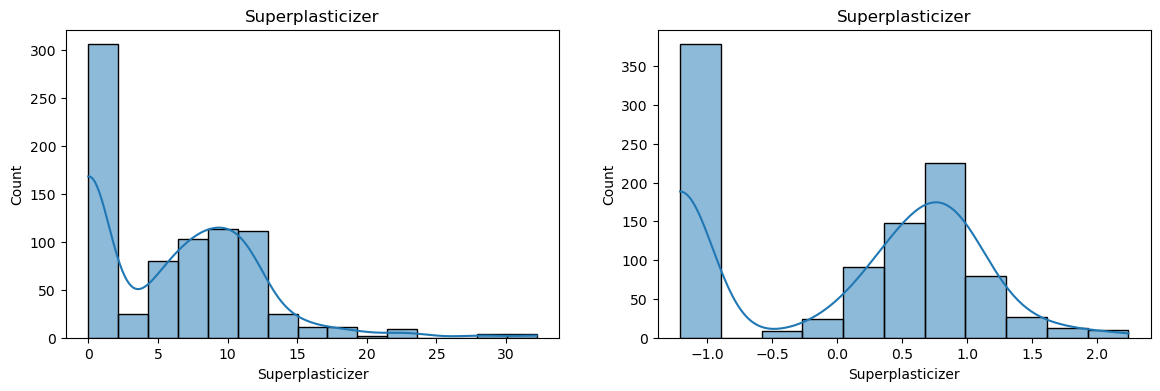

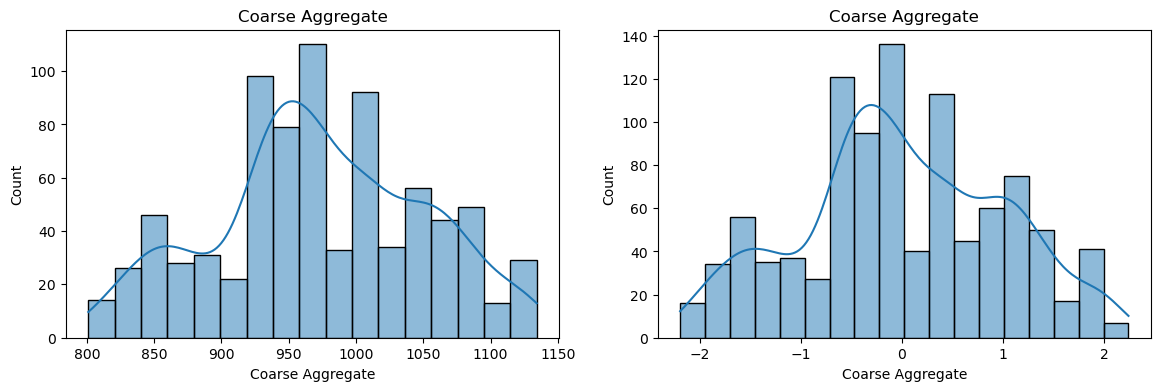

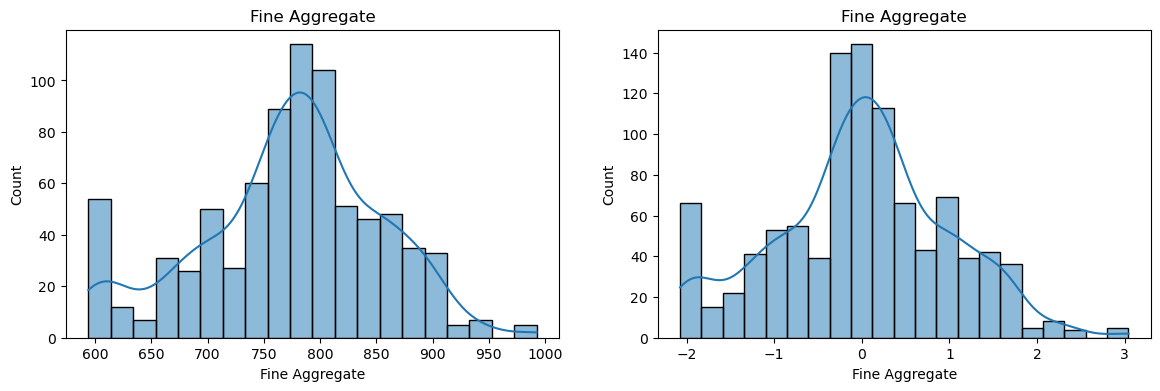

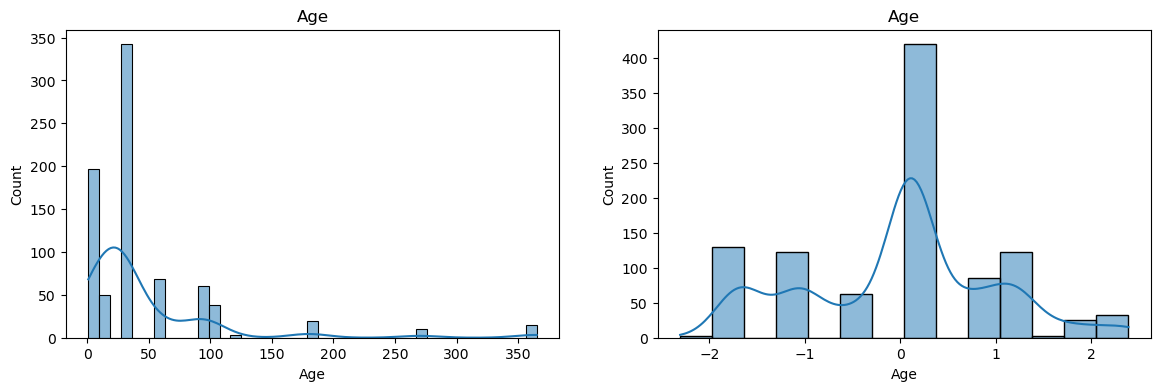

In [279]:
# before and after comparison for Yeo-Johnson plot
X_transformed_yeo = pd.DataFrame(X_transformed_yeo, columns= X_train.columns)
for col in X_transformed_yeo:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_transformed_yeo[col], kde = True)
    plt.title(col)

    plt.show()

In [280]:
# side by side lambdas
pd.DataFrame({'cols':X_train.columns, 'box-cox-lambdas':pt.lambdas_, 'yeo-johnson-lambdas':yeo_pt.lambdas_})

,cols,box-cox-lambdas,yeo-johnson-lambdas
0,Cement,0.116625,0.098283
1,Blast Furnace Slag,0.017022,0.001796
2,Fly Ash,-0.022280,-0.101005
3,Water,0.923823,0.949883
4,Superplasticizer,0.082137,0.242384
5,Coarse Aggregate,1.265407,1.198868
6,Fine Aggregate,1.825456,1.912998
7,Age,0.045667,0.005200
